In [1]:
import duckdb
import pandas as pd
import requests
import json
from datetime import datetime, timedelta
import os
from pathlib import Path
import geopandas as gpd
import xml.etree.ElementTree as ET
import re
from pathlib import Path


In [2]:
con = duckdb.connect()
con.sql("INSTALL ducklake; LOAD ducklake;")
con.sql("INSTALL spatial; LOAD spatial;")

In [3]:
con.sql(f"""
            ATTACH 'ducklake:mobility_ducklake.ducklake' AS my_ducklake;
            USE my_ducklake;
            CREATE SCHEMA IF NOT EXISTS silver;
                """)

In [4]:
con.sql("""SELECT count(*) as centroid_inside FROM silver.districts_zone WHERE ST_Contains(geometry, centroid);""").show()
con.sql(""" SELECT count(*) as centroid_outside FROM silver.districts_zone WHERE NOT ST_Contains(geometry, centroid);""").show()

┌─────────────────┐
│ centroid_inside │
│      int64      │
├─────────────────┤
│            3751 │
└─────────────────┘

┌──────────────────┐
│ centroid_outside │
│      int64       │
├──────────────────┤
│              158 │
└──────────────────┘



In [17]:
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from shapely import wkt, wkb

def map_outliers(df):


    if df.empty:
        print("✅ ¡Perfecto! No hay centroides fuera de sus zonas.")
        return None

    print(f"⚠️ Se encontraron {len(df)} casos donde el centroide está fuera.")

    # 2. Procesamiento con GeoPandas
    # Convertimos el texto WKT a objetos geométricos reales
    df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)))
    df['centroid'] = df['centroid'].apply(lambda x: wkb.loads(bytes(x)))
    df['visual_point'] = df['visual_point'].apply(lambda x: wkb.loads(bytes(x)))
    
    # Creamos un GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry='geometry')
    gdf.set_crs(epsg=4258, inplace=True)
    # 3. Crear el Mapa Interactivo (Folium)
    # Centramos el mapa en el primer error encontrado
    fig, ax = plt.subplots(figsize=(12, 12)) # Tamaño del gráfico
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()]
    
    # 2. Eliminar geometrías inválidas (opcional pero recomendado)
    # A veces un polígono se cruza a sí mismo y da problemas
    gdf = gdf[gdf.geometry.is_valid]
    # A) Pintamos los Polígonos (Zonas)
    gdf.plot(
        ax=ax, 
        color='lightblue', 
        edgecolor='blue', 
        alpha=0.5, 
        linewidth=1,
        label='Zona',aspect=None
    )

    # B) Pintamos los Centroides (Puntos Rojos)
    # Convertimos la columna de centroides en GeoSeries para poder plotearla
    gpd.GeoSeries(gdf['visual_point']).plot(
        ax=ax, 
        color='red', 
        markersize=20, 
        label='Centroide (Fuera)',
        marker='x' # Ponemos una X para que se vea bien
    )
    gpd.GeoSeries(gdf['centroid']).plot(
        ax=ax, 
        color='blue', 
        markersize=20, 
        label='Centroide (Fuera)',
        marker='x' # Ponemos una X para que se vea bien
    )

    # C) Decoración del Gráfico
    plt.title(f"Zonas con Centroides Desplazados )", fontsize=15)
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    
    # Quitamos la notación científica de los ejes si usas coordenadas UTM
    ax.ticklabel_format(useOffset=False, style='plain')

    # Añadir nombres (Opcional, puede ensuciar si hay muchos)
    if len(df) < 50: # Solo ponemos etiquetas si son pocos errores
        for idx, row in gdf.iterrows():
            ax.annotate(
                text=row['name'], 
                xy=(row['visual_point'].x, row['visual_point'].y),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred'
            )
            ax.annotate(
                text="real centroid", 
                xy=(row['centroid'].x, row['centroid'].y),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred'
            )

    plt.tight_layout()
    plt.show()

⚠️ Se encontraron 1 casos donde el centroide está fuera.


C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['centroid'] = df['centroid'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

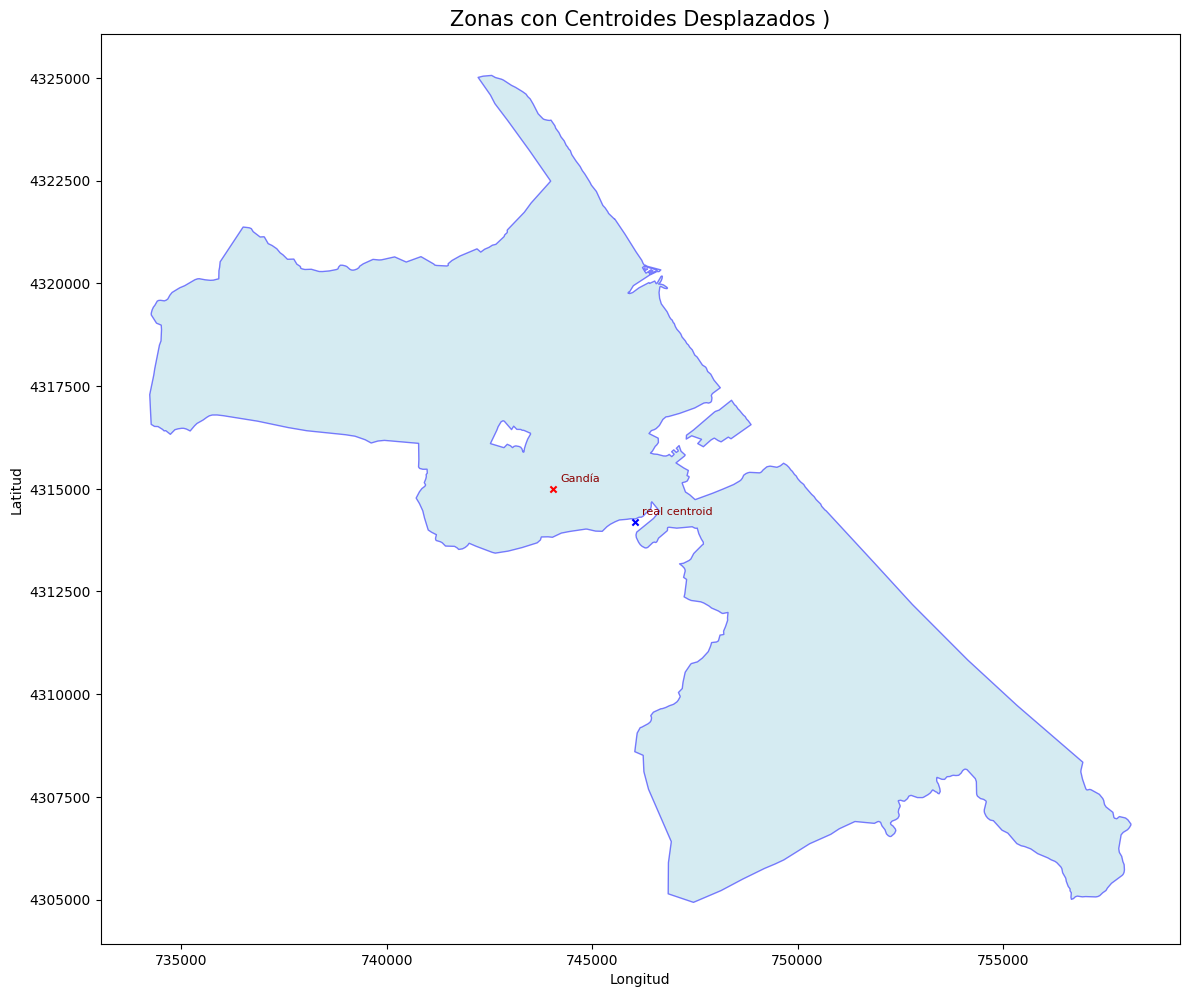

In [18]:
df = con.sql("""SELECT id_zone, name,
             ST_AsWKB(geometry) as geometry,
              ST_AsWKB(centroid) as centroid,
              ST_AsWKB(visual_point) visual_point
             
             FROM silver.gaus_zone WHERE NOT ST_Contains(geometry, centroid) --AND name LIKE 'Ali%'""").df()
map_outliers(df[1:2])

⚠️ Se encontraron 8 casos donde el centroide está fuera.


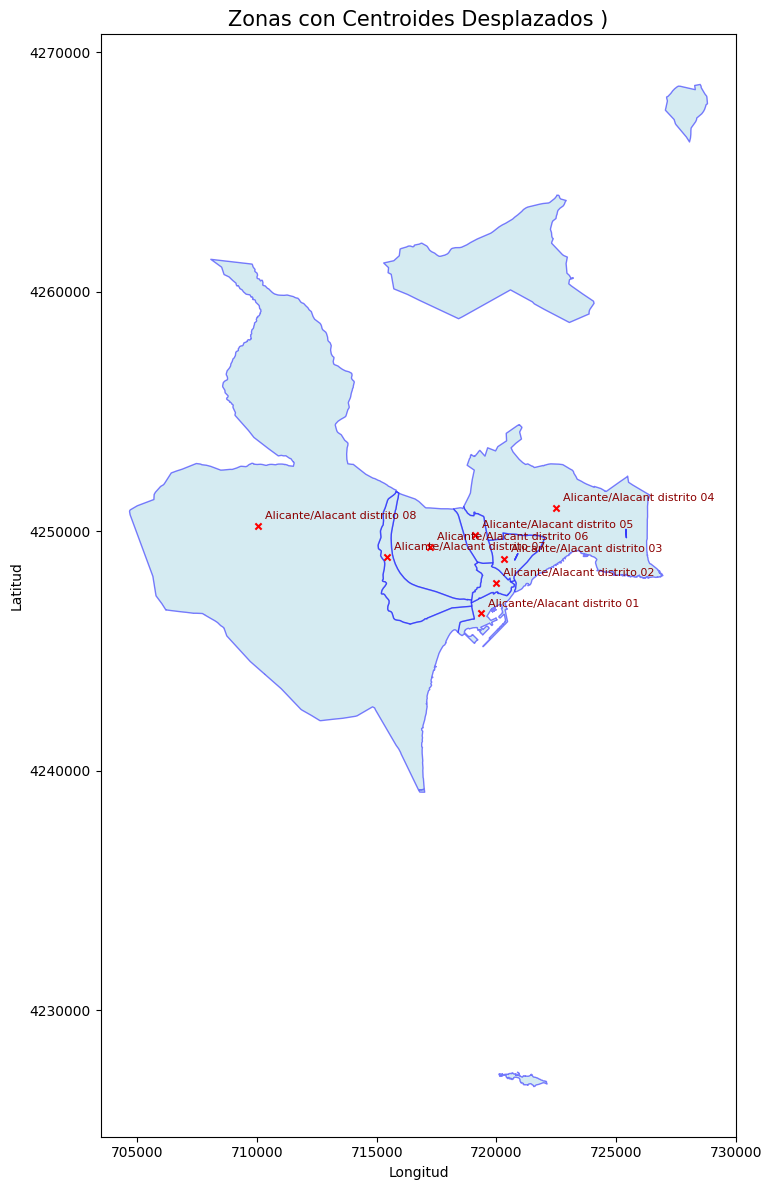

In [ ]:
df = con.sql("""SELECT id_zone, name,
             ST_AsWKB(geometry) as geometry,
              ST_AsWKB(centroid) as centroid,
              ST_AsWKB(visual_point) visual_point
             
             FROM silver.districts_zone WHERE ST_Contains(geometry, visual_point) AND name LIKE 'Ali%' --AND country_zone = 'EXT'""").df()
map_outliers(df)

⚠️ Se encontraron 1 casos donde el centroide está fuera.


C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['centroid'] = df['centroid'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

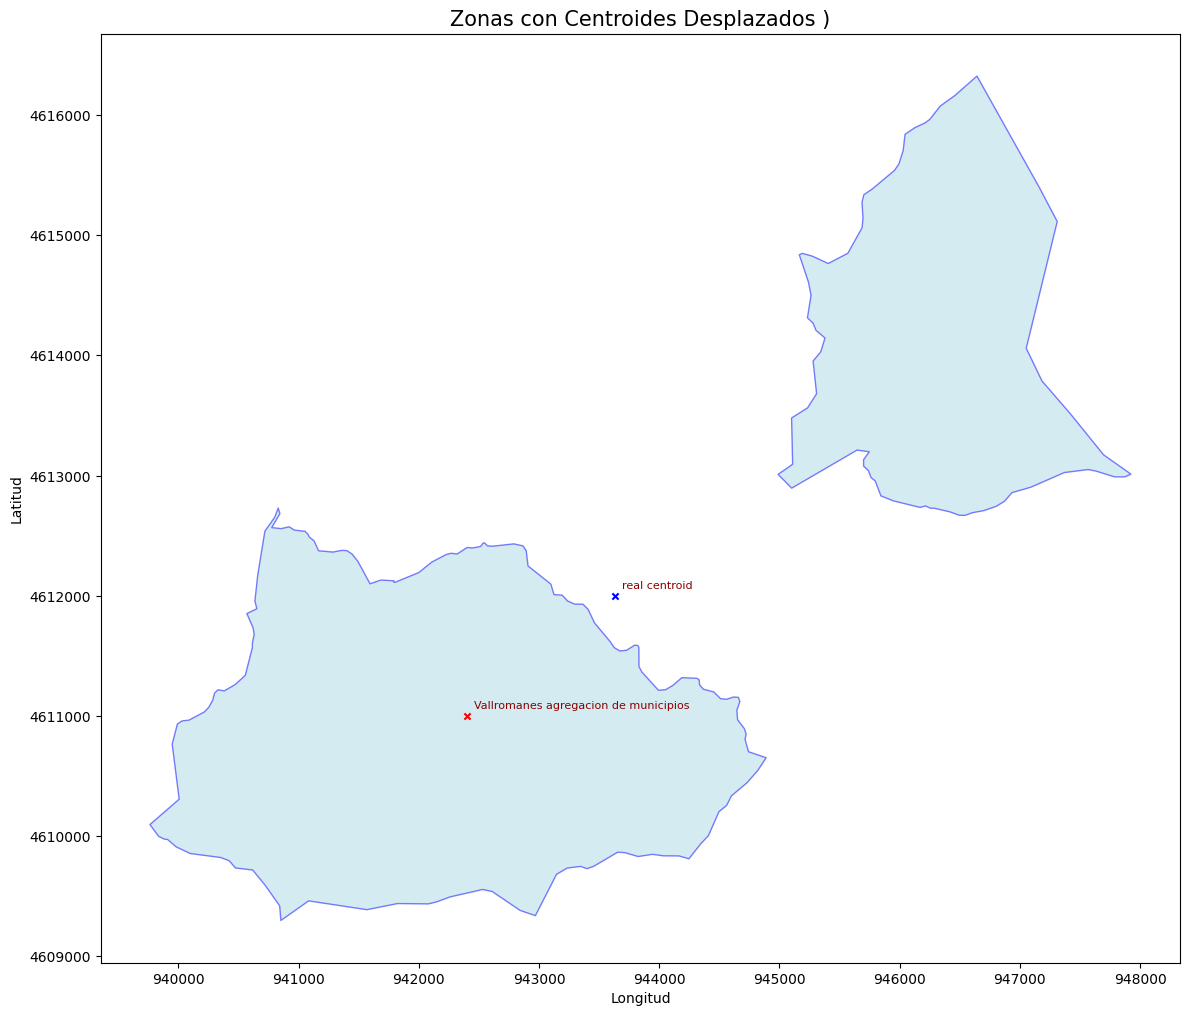

In [32]:
df = con.sql("""SELECT id_zone, name,
             ST_AsWKB(geometry) as geometry,
              ST_AsWKB(centroid) as centroid,
              ST_AsWKB(visual_point) visual_point
             
             FROM silver.districts_zone WHERE not ST_Contains(geometry, centroid) AND name LIKE 'Val%'""").df()
map_outliers(df[:1])

⚠️ Se encontraron 2 casos donde el centroide está fuera.


C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['centroid'] = df['centroid'].apply(lambda x: wkb.loads(bytes(x)))
C:\Users\Jorge\AppData\Local\Temp\ipykernel_17556\3234520992.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

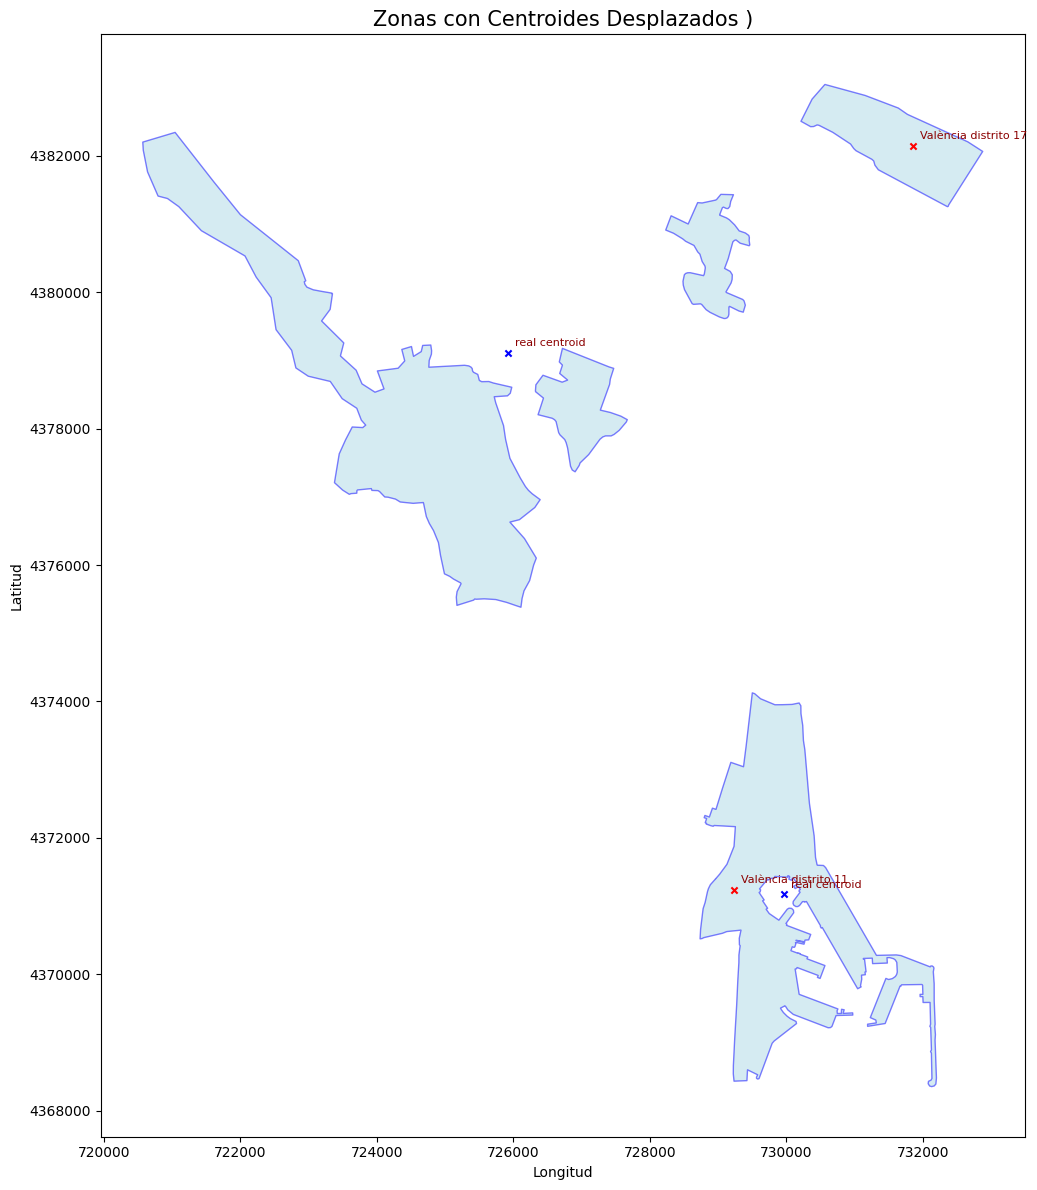

In [36]:
df = con.sql("""SELECT id_zone, name,
             ST_AsWKB(geometry) as geometry,
              ST_AsWKB(centroid) as centroid,
              ST_AsWKB(visual_point) visual_point
             
             FROM silver.districts_zone WHERE not ST_Contains(geometry, centroid) AND name LIKE 'Val%'""").df()
map_outliers(df[3:5])

⚠️ Se encontraron 115 casos donde el centroide está fuera.


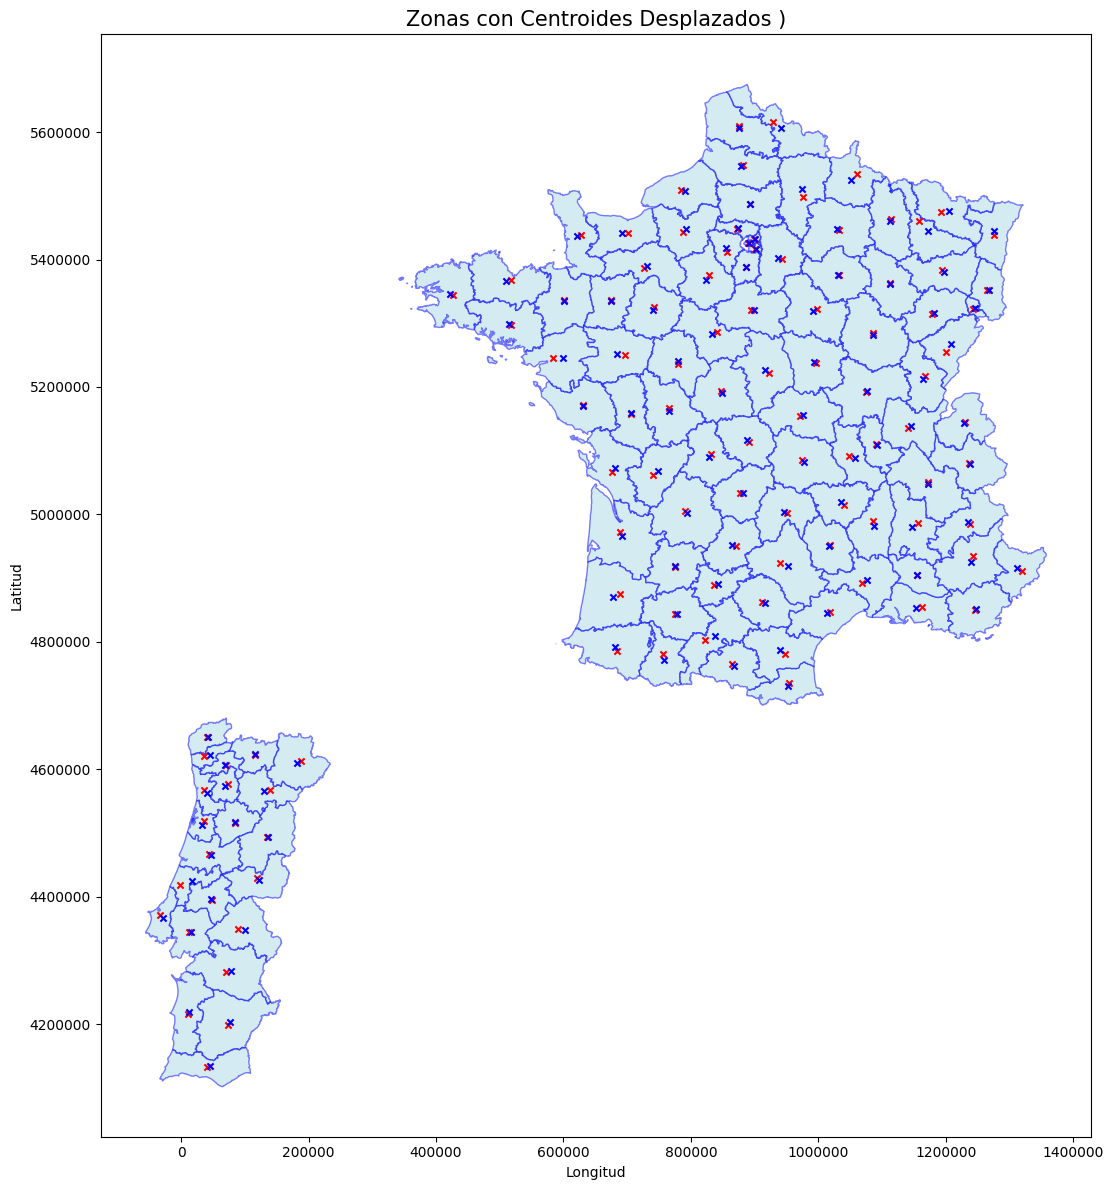

In [45]:
df = con.sql("""SELECT id_zone, name,
             ST_AsWKB(geometry) as geometry,
              ST_AsWKB(centroid) as centroid,
              ST_AsWKB(visual_point) visual_point
             
             FROM silver.districts_zone WHERE  ST_Contains(geometry, centroid) AND country_zone LIKE 'EXT%'""").df()
map_outliers(df)